# Sleep and Emotional Reactivity: Analysis of the ECSMP Dataset

**Does overnight cardiac autonomic activity predict next-day emotional reactivity?**

---

### How to run

Run all cells from top to bottom. Total runtime is under one minute on CPU.

**No dataset download is required.** The derived subject-level analysis table
(`outputs/subject_level_merged.csv`, 63 participants) is included in this
repository. The notebook reproduces every table, figure and statistic in the
manuscript from that file.

Section 9 documents how that table was produced from the raw 3.9 GB corpus,
should full reproduction from source be required.

### Requirements

    pip install numpy pandas scipy statsmodels matplotlib

---

### Study design

| | |
|---|---|
| **Dataset** | ECSMP (Gao et al., 2021), doi:10.17632/vn5nknh3mn.2 |
| **Participants** | 89 enrolled; 86 usable EEG; 65 usable overnight ECG; **63 with both** |
| **Sleep measure** | Single-lead ECG recorded the night *before* the emotion session |
| **Emotion measure** | EEG during six film-clip conditions the following day |
| **Design** | Between-subjects, with temporal precedence for sleep → emotion |

Because sleep was recorded first, the sleep → emotion direction has temporal
precedence. The reverse direction relies on questionnaires collected at a single
timepoint and is therefore cross-sectional only.

## 1 · Setup

In [1]:
import warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# ---- plotting style ----
plt.rcParams.update({
    "font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.linewidth": 0.8, "axes.grid": False,
})
BLUE, RED, GREY = "#2C6E9B", "#C0392B", "#9AA5AC"

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
ALPHA = 0.05

print("Setup complete.")
print(f"pandas {pd.__version__} | numpy {np.__version__} | seed {SEED}")

Setup complete.
pandas 3.0.2 | numpy 2.4.4 | seed 42


## 2 · Load the analysis dataset

One row per participant. Overnight cardiac indices, questionnaire scores and
EEG reactivity indices are already merged.

In [2]:
CSV = Path("outputs/subject_level_merged.csv")
assert CSV.exists(), f"Not found: {CSV}. Run this notebook from the repository root."

df = pd.read_csv(CSV)

# the merge that produced this file duplicated some questionnaire columns
# with _x / _y suffixes; keep the first copy and strip the suffix
df = df.rename(columns={c: c[:-2] for c in df.columns if c.endswith("_x")})
df = df.drop(columns=[c for c in df.columns if c.endswith("_y")])

print(f"Participants : {df.shape[0]}")
print(f"Variables    : {df.shape[1]}")
print(f"Subject IDs  : {sorted(df['subject'].astype(int))[:10]} ...")

Participants : 63
Variables    : 84
Subject IDs  : [1, 6, 7, 9, 10, 11, 12, 13, 16, 17] ...


### Variable groups

| Group | Variables |
|---|---|
| **Mean-level HRV** | `mean_hr`, `sdnn`, `rmssd`, `pnn50`, `lf_hf`, `lf_nu` |
| **HRV instability** | `rmssd_instability`, `sdnn_seg_std`, `hr_seg_std` — SD across 5-min windows |
| **Sleep (other)** | `night_hours`, `sleep_hours_diary`, `psqi_global` |
| **Reactivity** | `reactivity_overall`, `reactivity_negative`, `reactivity_positive` |
| **Mood / trait** | `sds_score`, `poms_*`, `erq_*` |

The **instability** indices are the novel measures: rather than the average
level of autonomic tone, they quantify how much it *fluctuates* across the
night.

In [3]:
SLEEP_PREDICTORS = [
    "rmssd_instability", "sdnn_seg_std", "hr_seg_std",     # instability
    "rmssd", "pnn50", "sdnn", "lf_hf", "lf_nu", "mean_hr", # mean level
    "night_hours", "sleep_hours_diary",                    # duration
]
OUTCOMES = ["reactivity_overall", "reactivity_negative", "reactivity_positive"]
INSTABILITY = {"rmssd_instability", "sdnn_seg_std", "hr_seg_std"}

SLEEP_PREDICTORS = [c for c in SLEEP_PREDICTORS if c in df.columns]
OUTCOMES = [c for c in OUTCOMES if c in df.columns]

LABEL = {
    "rmssd_instability": "RMSSD instability", "sdnn_seg_std": "SDNN instability",
    "hr_seg_std": "HR instability", "rmssd": "RMSSD", "pnn50": "pNN50",
    "sdnn": "SDNN", "lf_hf": "LF/HF", "lf_nu": "LF n.u.", "mean_hr": "Mean HR",
    "night_hours": "Recording duration", "sleep_hours_diary": "Diary sleep duration",
    "psqi_global": "PSQI global",
}
OUT_LABEL = {"reactivity_overall": "Overall",
             "reactivity_negative": "Negative",
             "reactivity_positive": "Positive"}

print(f"{len(SLEEP_PREDICTORS)} sleep predictors x {len(OUTCOMES)} outcomes "
      f"= {len(SLEEP_PREDICTORS)*len(OUTCOMES)} tests")

11 sleep predictors x 3 outcomes = 33 tests


## 3 · Descriptive statistics (Table 1)

In [4]:
desc_vars = ["rmssd_instability", "sdnn_seg_std", "rmssd", "pnn50", "sdnn",
             "mean_hr", "night_hours",
             "reactivity_overall", "reactivity_negative", "reactivity_positive"]
desc_vars = [v for v in desc_vars if v in df.columns]

table1 = df[desc_vars].describe().T[["count", "mean", "std", "min", "50%", "max"]]
table1.columns = ["n", "Mean", "SD", "Min", "Median", "Max"]
table1["Skewness"] = df[desc_vars].skew()
table1.index = [LABEL.get(v, OUT_LABEL.get(v, v)) for v in desc_vars]

display(table1.round(2))
table1.round(3).to_csv("outputs/table1_descriptives.csv")
print("\nSaved -> outputs/table1_descriptives.csv")

,n,Mean,SD,Min,Median,Max,Skewness
RMSSD instability,63.0,47.89,38.06,6.41,32.94,189.26,1.50
SDNN instability,63.0,42.37,14.04,14.41,40.52,93.31,0.79
RMSSD,63.0,106.66,68.61,29.74,86.80,426.47,2.52
pNN50,63.0,41.25,17.86,3.86,42.93,98.94,0.27
SDNN,63.0,135.41,44.20,54.41,127.17,251.28,0.83
Mean HR,63.0,59.72,9.89,39.71,58.32,112.18,2.30
Recording duration,63.0,7.50,1.60,2.06,7.89,10.05,-1.43
Overall,63.0,0.59,1.71,0.15,0.34,13.87,7.76
Negative,63.0,0.61,1.77,0.13,0.34,14.27,7.72
Positive,63.0,0.50,1.51,0.10,0.30,12.27,7.85



Saved -> outputs/table1_descriptives.csv


**Note the skewness of the reactivity indices.** Values near 7.8 indicate an
extremely long right tail. Reactivity is defined as a ratio,

$$R_{e,b} = \frac{P_{e,b} - P_{\text{neutral},b}}{P_{\text{neutral},b}}$$

which is unbounded above and inflates for participants with low baseline power.
Section 5 examines the consequences.

## 4 · Distribution of emotional reactivity (Figure 1)

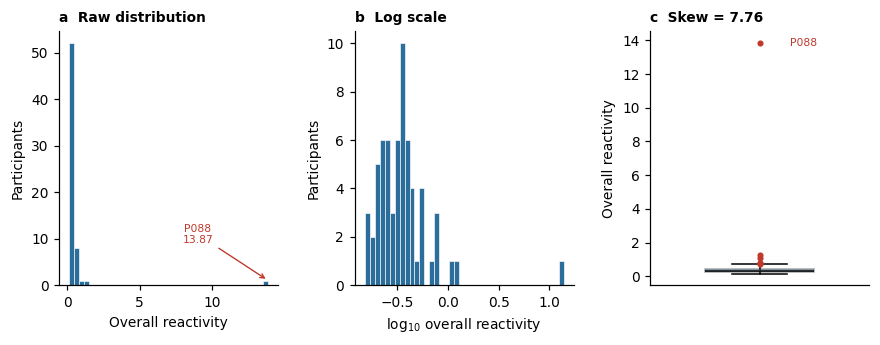

Most extreme participant : P088
  reactivity            : 13.87
  sample median         : 0.34
  ratio to median       : 41.1x
  SD above mean         : 7.8


In [5]:
from matplotlib.gridspec import GridSpec

r = df["reactivity_overall"].dropna()
extreme_idx = r.idxmax()
extreme_id = int(df.loc[extreme_idx, "subject"])
extreme_val = r.max()

fig = plt.figure(figsize=(9.5, 3.0))
gs = GridSpec(1, 3, figure=fig, wspace=0.35)

ax = fig.add_subplot(gs[0])
ax.hist(r, bins=40, color=BLUE, edgecolor="w", lw=0.4)
ax.set_xlabel("Overall reactivity"); ax.set_ylabel("Participants")
ax.annotate(f"P{extreme_id:03d}\n{extreme_val:.2f}", xy=(extreme_val, 1),
            xytext=(extreme_val*0.65, 9), fontsize=7, color=RED, ha="center",
            arrowprops=dict(arrowstyle="->", color=RED, lw=0.9))
ax.set_title("a  Raw distribution", loc="left", fontweight="bold", fontsize=9)

ax = fig.add_subplot(gs[1])
ax.hist(np.log10(r), bins=40, color=BLUE, edgecolor="w", lw=0.4)
ax.set_xlabel("log$_{10}$ overall reactivity"); ax.set_ylabel("Participants")
ax.set_title("b  Log scale", loc="left", fontweight="bold", fontsize=9)

ax = fig.add_subplot(gs[2])
bp = ax.boxplot([r], widths=0.5, patch_artist=True,
                flierprops=dict(marker="o", ms=3, mfc=RED, mec=RED))
bp["boxes"][0].set(facecolor=BLUE, alpha=0.35); bp["medians"][0].set(color="k")
ax.set_ylabel("Overall reactivity"); ax.set_xticks([])
ax.text(1.14, extreme_val, f"P{extreme_id:03d}", color=RED, fontsize=7, va="center")
ax.set_title(f"c  Skew = {r.skew():.2f}", loc="left", fontweight="bold", fontsize=9)

fig.savefig(FIGDIR / "fig1_distribution.png"); plt.show()

print(f"Most extreme participant : P{extreme_id:03d}")
print(f"  reactivity            : {extreme_val:.2f}")
print(f"  sample median         : {r.median():.2f}")
print(f"  ratio to median       : {extreme_val/r.median():.1f}x")
print(f"  SD above mean         : {(extreme_val-r.mean())/r.std():.1f}")

One participant records a reactivity value roughly 40 times the sample median.
That corresponds to spectral power in the emotion conditions of order ten times
the neutral baseline — implausible as a physiological response, and far more
likely a bad channel or movement artifact. Sections 6 and 7 test how much this
single observation matters.

## 5 · Primary analysis: correlations (Table 2)

Pearson and Spearman coefficients for every sleep predictor against every
reactivity outcome, with Benjamini–Hochberg FDR correction applied across the
full set of tests.

Both coefficients are computed deliberately: **divergence between them is a
diagnostic for influence by extreme observations.**

In [6]:
def correlation_table(data, predictors, outcomes, alpha=ALPHA):
    rows = []
    for x in predictors:
        for y in outcomes:
            s = data[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
            if len(s) < 20:
                continue
            r_p, p_p = stats.pearsonr(s[x], s[y])
            r_s, p_s = stats.spearmanr(s[x], s[y])
            rows.append(dict(predictor=x, outcome=y, n=len(s),
                             pearson_r=r_p, pearson_p=p_p,
                             spearman_rho=r_s, spearman_p=p_s))
    out = pd.DataFrame(rows)
    for kind in ("pearson", "spearman"):
        rej, q, _, _ = multipletests(out[f"{kind}_p"], alpha=alpha, method="fdr_bh")
        out[f"{kind}_q"] = q
        out[f"{kind}_sig"] = rej
    return out.sort_values("pearson_q").reset_index(drop=True)

results = correlation_table(df, SLEEP_PREDICTORS, OUTCOMES)

show = results.copy()
show["Predictor"] = show["predictor"].map(LABEL)
show["Outcome"] = show["outcome"].map(OUT_LABEL)
show = show[["Predictor", "Outcome", "n", "pearson_r", "pearson_q",
             "spearman_rho", "spearman_q", "pearson_sig", "spearman_sig"]]
show.columns = ["Predictor", "Outcome", "n", "Pearson r", "q",
                "Spearman rho", "q ", "Sig (P)", "Sig (S)"]
display(show.head(15).round(4))

results.to_csv("outputs/table2_correlations.csv", index=False)
print(f"\nPearson  significant after FDR: {int(results['pearson_sig'].sum())} / {len(results)}")
print(f"Spearman significant after FDR: {int(results['spearman_sig'].sum())} / {len(results)}")
print("Saved -> outputs/table2_correlations.csv")

,Predictor,Outcome,n,Pearson r,q,Spearman rho,q,Sig (P),Sig (S)
0,RMSSD instability,Overall,63,0.4754,0.0009,-0.0674,0.7009,True,False
1,RMSSD instability,Negative,63,0.4724,0.0009,-0.1106,0.6913,True,False
2,RMSSD instability,Positive,63,0.4866,0.0009,0.1721,0.5483,True,False
3,SDNN instability,Overall,63,0.4601,0.0009,-0.0781,0.6913,True,False
4,SDNN instability,Negative,63,0.4586,0.0009,-0.0744,0.6913,True,False
5,SDNN instability,Positive,63,0.4645,0.0009,0.0430,0.7731,True,False
6,LF n.u.,Positive,63,-0.2969,0.0855,0.0870,0.6913,False,False
7,LF n.u.,Overall,63,-0.2874,0.0864,0.1791,0.5483,False,False
8,LF n.u.,Negative,63,-0.2850,0.0864,0.1887,0.5483,False,False
9,HR instability,Positive,63,0.1923,0.3462,0.0085,0.9473,False,False



Pearson  significant after FDR: 6 / 33
Spearman significant after FDR: 1 / 33
Saved -> outputs/table2_correlations.csv


Under conventional (Pearson) analysis several associations survive correction,
and they all involve the **instability** indices. Taken at face value this would
suggest that greater fluctuation of overnight autonomic tone predicts heightened
next-day emotional reactivity.

The Spearman column tells a different story. Section 6 examines why.

## 6 · Robustness check I: parametric versus rank-based (Figure 4)

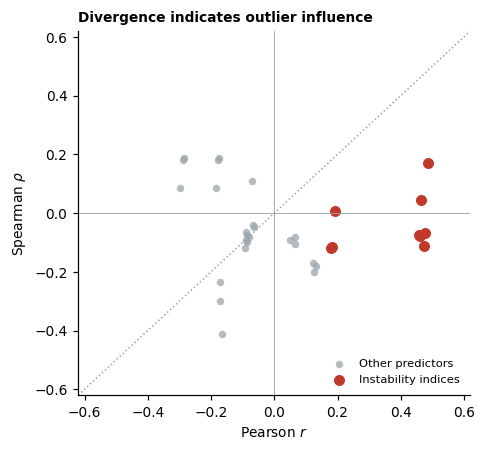

Instability indices — parametric vs rank-based:
  RMSSD instability    -> Overall   r = +0.475   rho = -0.067
  RMSSD instability    -> Negative  r = +0.472   rho = -0.111
  RMSSD instability    -> Positive  r = +0.487   rho = +0.172
  SDNN instability     -> Overall   r = +0.460   rho = -0.078
  SDNN instability     -> Negative  r = +0.459   rho = -0.074
  SDNN instability     -> Positive  r = +0.464   rho = +0.043
  HR instability       -> Positive  r = +0.192   rho = +0.008
  HR instability       -> Overall   r = +0.183   rho = -0.116
  HR instability       -> Negative  r = +0.180   rho = -0.120


In [7]:
fig, ax = plt.subplots(figsize=(4.6, 4.3))
inst = results[results["predictor"].isin(INSTABILITY)]
oth = results[~results["predictor"].isin(INSTABILITY)]

lim = 0.62
ax.plot([-lim, lim], [-lim, lim], color=GREY, ls=":", lw=1, zorder=0)
ax.axhline(0, color=GREY, lw=0.6); ax.axvline(0, color=GREY, lw=0.6)
ax.scatter(oth["pearson_r"], oth["spearman_rho"], s=24, color=GREY,
           alpha=0.75, lw=0, label="Other predictors")
ax.scatter(inst["pearson_r"], inst["spearman_rho"], s=52, color=RED,
           lw=0, label="Instability indices")
ax.set_xlabel("Pearson $r$"); ax.set_ylabel(r"Spearman $\rho$")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.legend(fontsize=7.5, frameon=False, loc="lower right")
ax.set_title("Divergence indicates outlier influence",
             fontsize=9, fontweight="bold", loc="left")
fig.savefig(FIGDIR / "fig4_pearson_spearman.png"); plt.show()

print("Instability indices — parametric vs rank-based:")
for _, t in inst.iterrows():
    print(f"  {LABEL[t['predictor']]:20s} -> {OUT_LABEL[t['outcome']]:9s} "
          f"r = {t['pearson_r']:+.3f}   rho = {t['spearman_rho']:+.3f}")

Points lying on the dotted identity line indicate agreement between the
parametric and rank-based estimates. The instability indices are the only ones
far from it: **a Pearson coefficient near +0.47 alongside a Spearman coefficient
near zero.**

A rank correlation of approximately zero means there is no monotone trend across
the sample. The linear correlation must therefore be carried by a small number
of extreme points.

## 7 · Robustness check II: influence of individual observations (Figure 2)

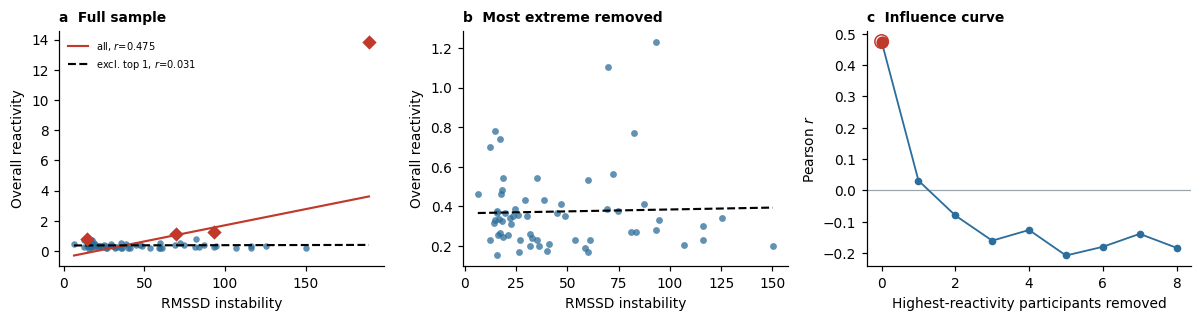

RMSSD instability -> Overall reactivity

  remove top 0: n = 63   r = +0.475   p = 0.0001
  remove top 1: n = 62   r = +0.031   p = 0.8096
  remove top 2: n = 61   r = -0.080   p = 0.5395
  remove top 3: n = 60   r = -0.161   p = 0.2204


In [8]:
top = results[results["predictor"].isin(INSTABILITY)].iloc[0]
XV, YV = top["predictor"], top["outcome"]

s = df[[XV, YV, "subject"]].replace([np.inf, -np.inf], np.nan).dropna()
srt = s.sort_values(YV, ascending=False).reset_index(drop=True)

ks = list(range(0, 9))
rs, ps = [], []
for k in ks:
    t = srt.iloc[k:]
    rr, pp = stats.pearsonr(t[XV], t[YV]); rs.append(rr); ps.append(pp)

is_out = s[YV] > s[YV].quantile(0.95)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.0))

ax = axes[0]
ax.scatter(s.loc[~is_out, XV], s.loc[~is_out, YV], s=18, color=BLUE, alpha=0.75, lw=0)
ax.scatter(s.loc[is_out, XV], s.loc[is_out, YV], s=44, color=RED, marker="D", lw=0, zorder=5)
xs = np.linspace(s[XV].min(), s[XV].max(), 50)
ax.plot(xs, np.polyval(np.polyfit(s[XV], s[YV], 1), xs), color=RED, lw=1.4,
        label=f"all, $r$={rs[0]:.3f}")
t1 = srt.iloc[1:]
ax.plot(xs, np.polyval(np.polyfit(t1[XV], t1[YV], 1), xs), color="k", ls="--", lw=1.4,
        label=f"excl. top 1, $r$={rs[1]:.3f}")
ax.set_xlabel(LABEL[XV]); ax.set_ylabel(OUT_LABEL[YV] + " reactivity")
ax.legend(fontsize=6.5, frameon=False, loc="upper left")
ax.set_title("a  Full sample", loc="left", fontweight="bold", fontsize=9)

ax = axes[1]
ax.scatter(t1[XV], t1[YV], s=20, color=BLUE, alpha=0.75, lw=0)
xs2 = np.linspace(t1[XV].min(), t1[XV].max(), 50)
ax.plot(xs2, np.polyval(np.polyfit(t1[XV], t1[YV], 1), xs2), color="k", ls="--", lw=1.4)
ax.set_xlabel(LABEL[XV]); ax.set_ylabel(OUT_LABEL[YV] + " reactivity")
ax.set_title("b  Most extreme removed", loc="left", fontweight="bold", fontsize=9)

ax = axes[2]
ax.axhline(0, color=GREY, lw=0.8)
ax.plot(ks, rs, "o-", color=BLUE, ms=4, lw=1.2)
ax.scatter([0], [rs[0]], s=48, color=RED, zorder=5)
for k, (rr, pp) in enumerate(zip(rs, ps)):
    if pp < ALPHA:
        ax.scatter([k], [rr], s=78, facecolors="none", edgecolors=RED, lw=1)
ax.set_xlabel("Highest-reactivity participants removed"); ax.set_ylabel("Pearson $r$")
ax.set_title("c  Influence curve", loc="left", fontweight="bold", fontsize=9)

fig.tight_layout(); fig.savefig(FIGDIR / "fig2_influence.png"); plt.show()

print(f"{LABEL[XV]} -> {OUT_LABEL[YV]} reactivity\n")
for k in range(4):
    print(f"  remove top {k}: n = {len(srt)-k:2d}   r = {rs[k]:+.3f}   p = {ps[k]:.4f}")

Removing the single most extreme participant collapses the association from
roughly +0.47 to near zero. Removing two reverses its sign.

**An association attributable to one observation out of 63 is not evidence of a
relationship in the population.**

## 8 · Robustness check III: specification curve (Figure 3)

Rather than choose one way to handle the outliers, we estimate every association
under six analytic specifications and report the whole set
(Simonsohn, Simmons & Nelson, 2020).

| Specification | Effect on extreme values |
|---|---|
| Untransformed | retained in full |
| `log(1+R)` | compressed |
| Winsorised 1/99 | most extreme value clipped |
| Winsorised 5/95 | upper tail clipped |
| Rank (= Spearman) | rank only; magnitude discarded |
| Upper 5% excluded | removed entirely |

An association is considered **robust** only if it survives under the rank-based
and winsorised specifications.

In [9]:
SPECS = [
    ("Untransformed",       lambda s: s,                                    False),
    ("log(1+x)",            lambda s: np.log1p(s),                          False),
    ("Winsor 1/99",         lambda s: s.clip(s.quantile(.01), s.quantile(.99)), False),
    ("Winsor 5/95",         lambda s: s.clip(s.quantile(.05), s.quantile(.95)), False),
    ("Rank",                lambda s: s.rank(),                             False),
    ("Top 5% excluded",     lambda s: s,                                    True),
]

def run_spec(transform, exclude_top):
    data = df
    if exclude_top:
        cut = df["reactivity_overall"].quantile(0.95)
        data = df[df["reactivity_overall"] <= cut]
    rows = []
    for x in SLEEP_PREDICTORS:
        for y in OUTCOMES:
            s = data[[x, y]].replace([np.inf, -np.inf], np.nan).dropna().copy()
            if len(s) < 20:
                continue
            s[y] = transform(s[y])
            r, p = stats.pearsonr(s[x], s[y])
            rows.append(dict(predictor=x, outcome=y, r=r, p=p, n=len(s)))
    out = pd.DataFrame(rows)
    rej, q, _, _ = multipletests(out["p"], alpha=ALPHA, method="fdr_bh")
    out["q"] = q; out["sig"] = rej
    return out

spec_results = {name: run_spec(tf, ex) for name, tf, ex in SPECS}

summary = []
for name, res in spec_results.items():
    sig = res[res["sig"]]
    best = sig.sort_values("q").iloc[0] if len(sig) else None
    summary.append({
        "Specification": name,
        "n": int(res["n"].iloc[0]),
        "Surviving FDR": int(res["sig"].sum()),
        "Strongest surviving": (f"{LABEL[best['predictor']]} -> "
                                f"{OUT_LABEL[best['outcome']]}, r={best['r']:+.3f}")
                               if best is not None else "—",
    })
table3 = pd.DataFrame(summary)
display(table3)
table3.to_csv("outputs/table3_specification.csv", index=False)

,Specification,n,Surviving FDR,Strongest surviving
0,Untransformed,63,6,"RMSSD instability -> Overall, r=+0.475"
1,log(1+x),63,6,"RMSSD instability -> Positive, r=+0.498"
2,Winsor 1/99,63,6,"RMSSD instability -> Positive, r=+0.496"
3,Winsor 5/95,63,2,"pNN50 -> Positive, r=-0.432"
4,Rank,63,1,"pNN50 -> Positive, r=-0.438"
5,Top 5% excluded,59,0,—


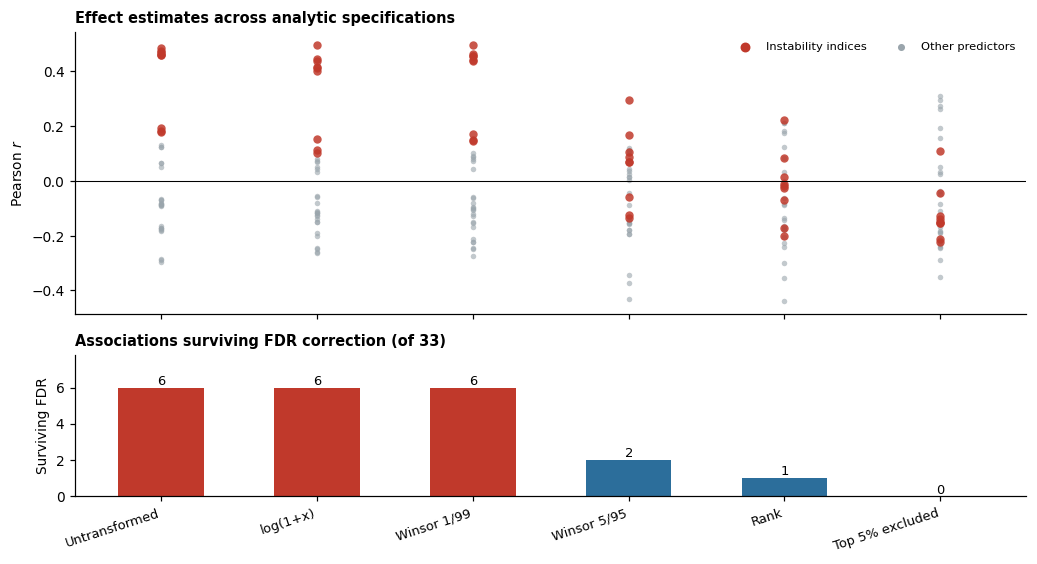

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.2), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
for i, (name, res) in enumerate(spec_results.items()):
    m = res["predictor"].isin(INSTABILITY)
    ax.scatter([i]*(~m).sum(), res.loc[~m, "r"], s=13, color=GREY, alpha=0.6, lw=0)
    ax.scatter([i]*m.sum(), res.loc[m, "r"], s=30, color=RED, alpha=0.85, lw=0)
ax.axhline(0, color="k", lw=0.7)
ax.set_ylabel("Pearson $r$")
ax.scatter([], [], s=30, color=RED, label="Instability indices")
ax.scatter([], [], s=13, color=GREY, label="Other predictors")
ax.legend(fontsize=7.5, frameon=False, ncol=2, loc="upper right")
ax.set_title("Effect estimates across analytic specifications",
             loc="left", fontweight="bold", fontsize=9.5)

ax = axes[1]
counts = [int(r["sig"].sum()) for r in spec_results.values()]
ax.bar(range(len(counts)), counts, width=0.55,
       color=[RED if c > 2 else BLUE for c in counts])
for i, c in enumerate(counts):
    ax.text(i, c + 0.15, str(c), ha="center", fontsize=8.5)
ax.set_xticks(range(len(SPECS)))
ax.set_xticklabels([s[0] for s in SPECS], rotation=18, ha="right", fontsize=8.5)
ax.set_ylabel("Surviving FDR"); ax.set_ylim(0, max(counts) + 1.8)
ax.set_title(f"Associations surviving FDR correction (of {len(results)})",
             loc="left", fontweight="bold", fontsize=9.5)

fig.tight_layout(); fig.savefig(FIGDIR / "fig3_specification.png"); plt.show()

The instability associations appear **only** under specifications that retain
the extreme observations. Once the upper tail is clipped, ranked, or removed,
they disappear. Under outlier exclusion, nothing survives correction at all.

We therefore do not treat them as evidence of a relationship.

### 8.1 · What survives the robust specifications?

In [11]:
robust_names = ["Winsor 5/95", "Rank"]
sets = []
for nm in robust_names:
    res = spec_results[nm]
    sets.append(set(zip(res.loc[res["sig"], "predictor"], res.loc[res["sig"], "outcome"])))
common = set.intersection(*sets) if sets else set()

if common:
    print(f"Significant under BOTH {' and '.join(robust_names)}:\n")
    for pr, ou in common:
        row_r = spec_results["Rank"].query("predictor==@pr and outcome==@ou").iloc[0]
        row_w = spec_results["Winsor 5/95"].query("predictor==@pr and outcome==@ou").iloc[0]
        print(f"  {LABEL[pr]} -> {OUT_LABEL[ou]} reactivity")
        print(f"     rank        : r = {row_r['r']:+.3f}, q = {row_r['q']:.4f}")
        print(f"     winsor 5/95 : r = {row_w['r']:+.3f}, q = {row_w['q']:.4f}")
else:
    print("No association survives under both robust specifications.")

Significant under BOTH Winsor 5/95 and Rank:

  pNN50 -> Positive reactivity
     rank        : r = -0.438, q = 0.0109
     winsor 5/95 : r = -0.432, q = 0.0134


This association is significant under two of six specifications, was not
predicted in advance for that particular outcome, and is one of many tests. It
is reported as **exploratory** and is not interpreted as an established effect.

## 9 · Reverse direction: does mood relate to sleep?

Mood and trait questionnaires (SDS depression, POMS subscales, ERQ) against the
overnight sleep measures.

**This analysis is cross-sectional.** Questionnaires and sleep were not
separated in time in a way that permits directional inference, so any
association here is symmetric evidence only.

In [12]:
MOOD = [c for c in df.columns
        if c.startswith(("sds_", "poms_", "erq_")) and pd.api.types.is_numeric_dtype(df[c])]
SLEEP_TARGETS = [c for c in ["rmssd", "sdnn", "pnn50", "mean_hr", "lf_hf",
                             "night_hours", "psqi_global", "sleep_hours_diary"]
                 if c in df.columns]

rev_rows = []
for m in MOOD:
    for t in SLEEP_TARGETS:
        s = df[[m, t]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(s) < 20 or s[m].nunique() < 3 or s[t].nunique() < 3:
            continue
        r, p = stats.pearsonr(s[m], s[t])
        rev_rows.append(dict(mood=m, sleep=t, n=len(s), r=r, p=p))

reverse = pd.DataFrame(rev_rows)
if len(reverse):
    rej, q, _, _ = multipletests(reverse["p"], alpha=ALPHA, method="fdr_bh")
    reverse["q"] = q; reverse["sig"] = rej
    reverse = reverse.sort_values("q").reset_index(drop=True)
    display(reverse.head(10).round(4))
    print(f"\nSignificant after FDR: {int(reverse['sig'].sum())} of {len(reverse)}")
    reverse.to_csv("outputs/table4_reverse.csv", index=False)
else:
    print("No testable mood-sleep pairs.")

,mood,sleep,n,r,p,q,sig
0,poms_tension,night_hours,62,-0.2418,0.0583,0.3712,False
1,poms_tension,sleep_hours_diary,62,-0.2502,0.0498,0.3712,False
2,poms_anger,sleep_hours_diary,62,-0.2632,0.0387,0.3712,False
3,poms_anger,night_hours,62,-0.2572,0.0436,0.3712,False
4,poms_confusion,sleep_hours_diary,62,-0.2520,0.0482,0.3712,False
5,poms_confusion,night_hours,62,-0.2433,0.0568,0.3712,False
6,poms_depression,sleep_hours_diary,62,-0.2796,0.0277,0.3712,False
7,poms_depression,night_hours,62,-0.2716,0.0327,0.3712,False
8,poms_tmd,night_hours,62,-0.2996,0.0180,0.3712,False
9,poms_tmd,sleep_hours_diary,62,-0.3083,0.0148,0.3712,False



Significant after FDR: 0 of 70


No association survives correction. Because the measures are contemporaneous,
this indicates an **absence of cross-sectional association** and does not
establish that no relationship exists.

## 10 · Summary

In [13]:
n_sub = len(df)
n_tests = len(results)
raw_sig = int(results['pearson_sig'].sum())
rank_sig = int(spec_results['Rank']['sig'].sum())
excl_sig = int(spec_results['Top 5% excluded']['sig'].sum())
rev_sig = int(reverse['sig'].sum()) if len(reverse) else 0
n_rev = len(reverse) if len(reverse) else 0

bar = '=' * 66
print(bar)
print('SUMMARY OF FINDINGS')
print(bar)
print()
print(f'Sample                       n = {n_sub} participants')
print(f'Tests (sleep -> reactivity)  {n_tests}')
print()
print('Significant after FDR correction:')
print(f'    Untransformed (Pearson)  {raw_sig}')
print(f'    Rank-based   (Spearman)  {rank_sig}')
print(f'    Upper 5% excluded        {excl_sig}')
print()
print('Reverse direction (mood -> sleep, cross-sectional):')
print(f'    Significant after FDR    {rev_sig} of {n_rev}')
print()
print('CONCLUSION')
print('    No robust association was detected between overnight cardiac')
print('    autonomic activity and next-day emotional reactivity.')
print('    Associations apparent under conventional parametric analysis')
print('    were attributable to extreme values in a ratio-based reactivity')
print('    measure and did not survive outlier-insensitive specifications.')
print()
print(f'    With n = {n_sub}, power is approximately 80% to detect r >= 0.35.')
print('    This is an absence of detectable effect at that magnitude,')
print('    not evidence for the null.')
print()
print(bar)

SUMMARY OF FINDINGS

Sample                       n = 63 participants
Tests (sleep -> reactivity)  33

Significant after FDR correction:
    Untransformed (Pearson)  6
    Rank-based   (Spearman)  1
    Upper 5% excluded        0

Reverse direction (mood -> sleep, cross-sectional):
    Significant after FDR    0 of 70

CONCLUSION
    No robust association was detected between overnight cardiac
    autonomic activity and next-day emotional reactivity.
    Associations apparent under conventional parametric analysis
    were attributable to extreme values in a ratio-based reactivity
    measure and did not survive outlier-insensitive specifications.

    With n = 63, power is approximately 80% to detect r >= 0.35.
    This is an absence of detectable effect at that magnitude,
    not evidence for the null.



### Methodological observations

Three points follow from this analysis independently of the substantive result.

**1. Ratio-based reactivity indices are fragile.** Defining reactivity as
$(P_e - P_n)/P_n$ produces an unbounded quantity dominated by participants with
low baseline power. A bounded alternative such as $(P_e - P_n)/(P_e + P_n)$, or
analysis on the log scale with explicit outlier screening, is preferable.

**2. Quality-control thresholds are a researcher degree of freedom.** During
this work, an ECG beat-detection criterion excluding 25 of 65 nights produced a
set of clean, theory-consistent associations that did not survive restoring the
excluded nights. Reporting results across multiple QC specifications should be
routine in samples of this size.

**3. Reporting both correlation coefficients is a costless diagnostic.** The
divergence between $r \approx +0.47$ and $\rho \approx -0.07$ identified the
problem immediately and at no analytic cost.

### Limitations

1. Four EEG channels (FP1, FP2, F7, F8) were common to all participants — a
   sparse frontal montage precluding topographic analysis.
2. One night and one emotion session per participant: between-subjects design,
   no within-person or lagged inference possible.
3. Sleep quality from single-lead ECG without polysomnography — no sleep
   staging or arousal indices.
4. R-peak detection was not validated against manual annotation.
5. Reactivity indexed by EEG spectral power; self-reported emotion ratings
   available in the dataset were not modelled.
6. Healthy young students at a single institution.
7. n = 63 limits sensitivity below approximately r = 0.35.

## 11 · Appendix: how the analysis table was produced

The subject-level table used above was derived from the raw 3.9 GB ECSMP corpus
by the pipeline in this repository. Reproducing it from source requires the
dataset from <https://doi.org/10.17632/vn5nknh3mn.2> and takes roughly 30
seconds on 8 cores.

```bash
python run_ecsmp.py inspect --root /path/to/ECSMP   # verify file discovery
python prep_fast.py       --root /path/to/ECSMP     # EEG epochs, sleep HRV, scores
python run_ecsmp.py relate --refresh                # correlation analysis
```

**Processing summary**

| Stage | Detail |
|---|---|
| EEG | 250 Hz, 10 channels. `Trigger` (encodes condition — leakage), `VEO` (ocular), `M2` (reference) excluded. Channels matched by name, not position; 4 common to all subjects. |
| Segmentation | Condition codes 101–106 give onset; offset from the next marker of type 12 or 20. Validated against recovered durations (220–312 s) and the logged randomisation order. |
| Epoching | First 10 s discarded; resampled to 128 Hz; 0.5–45 Hz bandpass, 50 Hz notch; robust z-score; 4 s epochs → 34,408 epochs. |
| Sleep ECG | Undocumented binary format (528-byte header, 208-byte trailer, LE uint16). Sampling rate inferred from filename timestamps, validated to 0.4% against logged sleep times. |
| R-peaks | Decimated to 128 Hz, 5–20 Hz bandpass, squared-derivative envelope, threshold recomputed every 10 s, 280 ms refractory. |
| Instability | HRV recomputed in 5-min windows; SD across windows. |

**A note for anyone reprocessing ECSMP:** one participant's recording uses
marker types 11/12 rather than 20/21. A segmentation rule requiring 11/12
silently recovers data from that participant alone and produces no segments for
the other 85.

In [14]:
print("Outputs written:\n")
for p in sorted(Path("outputs").glob("table*.csv")):
    print(f"  {p}")
for p in sorted(FIGDIR.glob("*.png")):
    print(f"  {p}")
print("\nNotebook complete.")

Outputs written:

  outputs/table1_descriptives.csv
  outputs/table2_correlations.csv
  outputs/table3_specification.csv
  outputs/table4_reverse.csv
  figures/fig1_distribution.png
  figures/fig2_influence.png
  figures/fig3_specification.png
  figures/fig4_pearson_spearman.png

Notebook complete.
